Dataset:
    StudyHours  Attendance  Assignments  Pass
0            2          60            3     0
1            5          85            8     1
2            1          55            2     0
3            6          90            9     1
4            3          70            5     0
5            8          95           10     1
6            2          65            4     0
7            7          88            9     1
8            4          75            6     1
9            9          98           10     1
10           1          50            1     0
11           5          82            7     1
12           6          91            9     1
13           3          68            4     0
14           8          94           10     1
15           2          58            3     0
16           7          89            8     1
17           4          72            5     0
18           9          97           10     1
19           3          65            4     0

Bagging Performance
Accu

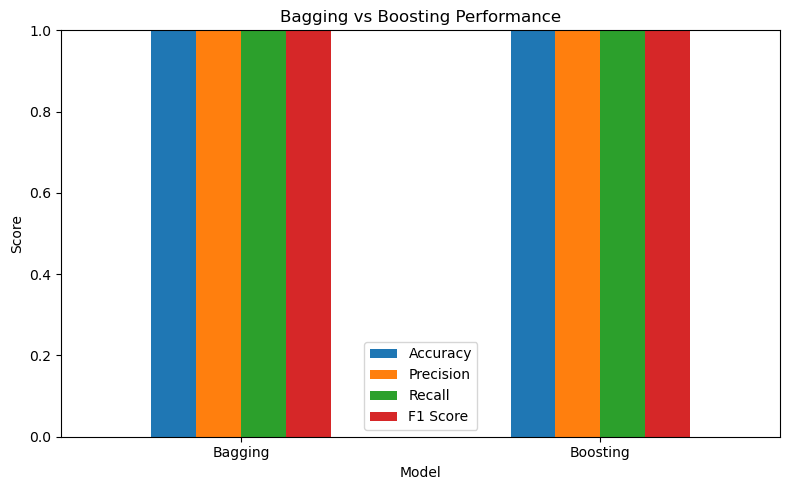

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

data = {
    "StudyHours": [2, 5, 1, 6, 3, 8, 2, 7, 4, 9, 1, 5, 6, 3, 8, 2, 7, 4, 9, 3],
    "Attendance": [60, 85, 55, 90, 70, 95, 65, 88, 75, 98, 50, 82, 91, 68, 94, 58, 89, 72, 97, 65],
    "Assignments": [3, 8, 2, 9, 5, 10, 4, 9, 6, 10, 1, 7, 9, 4, 10, 3, 8, 5, 10, 4],
    "Pass": [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

X = df[["StudyHours", "Attendance", "Assignments"]]
y = df["Pass"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=10,
    random_state=42
)

boosting = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=10,
    random_state=42
)

bagging.fit(X_train, y_train)
boosting.fit(X_train, y_train)

bagging_pred = bagging.predict(X_test)
boosting_pred = boosting.predict(X_test)

bagging_accuracy = accuracy_score(y_test, bagging_pred)
bagging_precision = precision_score(y_test, bagging_pred)
bagging_recall = recall_score(y_test, bagging_pred)
bagging_f1 = f1_score(y_test, bagging_pred)

boosting_accuracy = accuracy_score(y_test, boosting_pred)
boosting_precision = precision_score(y_test, boosting_pred)
boosting_recall = recall_score(y_test, boosting_pred)
boosting_f1 = f1_score(y_test, boosting_pred)

results = pd.DataFrame({
    "Model": ["Bagging", "Boosting"],
    "Accuracy": [bagging_accuracy, boosting_accuracy],
    "Precision": [bagging_precision, boosting_precision],
    "Recall": [bagging_recall, boosting_recall],
    "F1 Score": [bagging_f1, boosting_f1]
})

print("\nBagging Performance")
print("Accuracy:", bagging_accuracy)
print("Precision:", bagging_precision)
print("Recall:", bagging_recall)
print("F1 Score:", bagging_f1)

print("\nBoosting Performance")
print("Accuracy:", boosting_accuracy)
print("Precision:", boosting_precision)
print("Recall:", boosting_recall)
print("F1 Score:", boosting_f1)

print("\nPerformance Comparison")
print(results)

results.set_index("Model").plot(kind="bar", figsize=(8, 5))
plt.title("Bagging vs Boosting Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN     

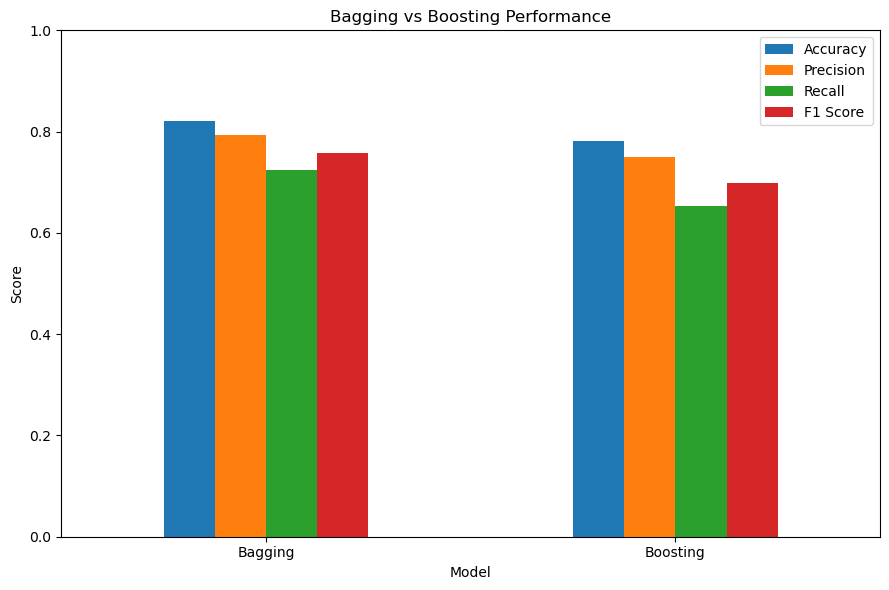

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv("train.csv")

print("Dataset:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

columns_to_drop = ["PassengerId", "Name", "Ticket", "Cabin"]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

if "Embarked" in df.columns:
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

for column in df.select_dtypes(include=["object"]).columns:
    df[column] = LabelEncoder().fit_transform(df[column].astype(str))

df = df.dropna()

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

boosting = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

bagging.fit(X_train, y_train)
boosting.fit(X_train, y_train)

bagging_pred = bagging.predict(X_test)
boosting_pred = boosting.predict(X_test)

bagging_accuracy = accuracy_score(y_test, bagging_pred)
bagging_precision = precision_score(y_test, bagging_pred)
bagging_recall = recall_score(y_test, bagging_pred)
bagging_f1 = f1_score(y_test, bagging_pred)

boosting_accuracy = accuracy_score(y_test, boosting_pred)
boosting_precision = precision_score(y_test, boosting_pred)
boosting_recall = recall_score(y_test, boosting_pred)
boosting_f1 = f1_score(y_test, boosting_pred)

print("\nBAGGING PERFORMANCE")
print("Accuracy:", bagging_accuracy)
print("Precision:", bagging_precision)
print("Recall:", bagging_recall)
print("F1 Score:", bagging_f1)

print("\nBagging Confusion Matrix:")
print(confusion_matrix(y_test, bagging_pred))

print("\nBOOSTING PERFORMANCE")
print("Accuracy:", boosting_accuracy)
print("Precision:", boosting_precision)
print("Recall:", boosting_recall)
print("F1 Score:", boosting_f1)

print("\nBoosting Confusion Matrix:")
print(confusion_matrix(y_test, boosting_pred))

results = pd.DataFrame({
    "Model": ["Bagging", "Boosting"],
    "Accuracy": [bagging_accuracy, boosting_accuracy],
    "Precision": [bagging_precision, boosting_precision],
    "Recall": [bagging_recall, boosting_recall],
    "F1 Score": [bagging_f1, boosting_f1]
})

print("\nMODEL PERFORMANCE COMPARISON")
print(results)

results.set_index("Model").plot(kind="bar", figsize=(9, 6))
plt.title("Bagging vs Boosting Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

